In [8]:
import os
import json
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter

In [2]:
# --- Define data paths ---
IMG_ROOT = "data/railsem19/jpgs/rs19_val"
MASK_ROOT = "data/railsem19/uint8/rs19_val"

assert os.path.exists(IMG_ROOT), f"Image directory not found: {IMG_ROOT}"
assert os.path.exists(MASK_ROOT), f"Mask directory not found: {MASK_ROOT}"

In [3]:
# --- Get all images and masks ---
images = sorted([f for f in os.listdir(IMG_ROOT) if f.endswith('.jpg')])
masks = sorted([f for f in os.listdir(MASK_ROOT) if f.endswith('.png')])

img_paths = [os.path.join(IMG_ROOT, f) for f in images]
mask_paths = [os.path.join(MASK_ROOT, f) for f in masks]

print(f"Total image-mask pairs: {len(img_paths)}")

Total image-mask pairs: 8500


In [52]:
for mask in masks[:5]:
    print(mask)

rs00000.png
rs00001.png
rs00002.png
rs00003.png
rs00004.png


In [45]:
images[0]

'rs00000.jpg'

In [47]:
mask_file_0 = mask_paths[0]
mask_0 = Image.open(mask_file_0)
mask_arr_0 = np.array(mask_0, dtype=np.int64)
mask_arr_0.shape

(1080, 1920)

In [48]:
mask_arr_0.dtype

dtype('int64')


Sample 289: rs00288.jpg
- Image size: (1920, 1080)
- Mask size:  (1920, 1080)
- Unique classes in mask: [ 0  1  2  4  5  7  8  9 10 12 15 17]


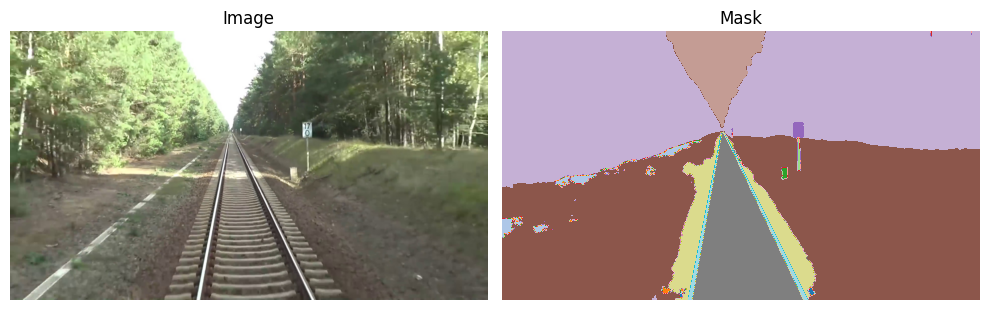


Sample 4898: rs04897.jpg
- Image size: (1920, 1080)
- Mask size:  (1920, 1080)
- Unique classes in mask: [  2   4   5   8   9  10  12  13  15  17 255]


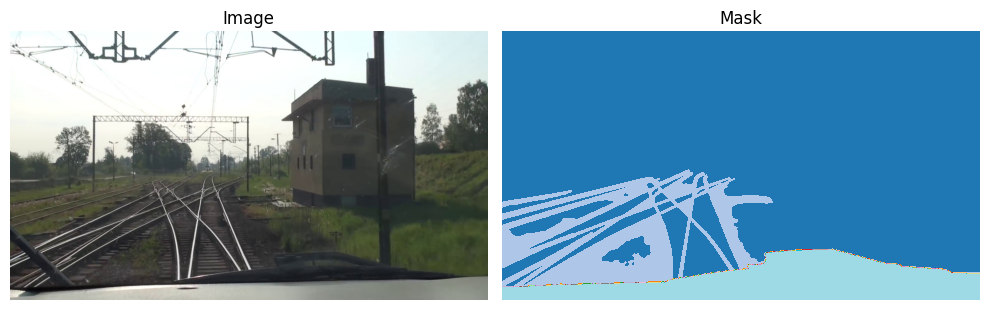


Sample 2796: rs02795.jpg
- Image size: (1920, 1080)
- Mask size:  (1920, 1080)
- Unique classes in mask: [  0   1   2   4   5   6   7   8   9  10  11  12  13  15  17 255]


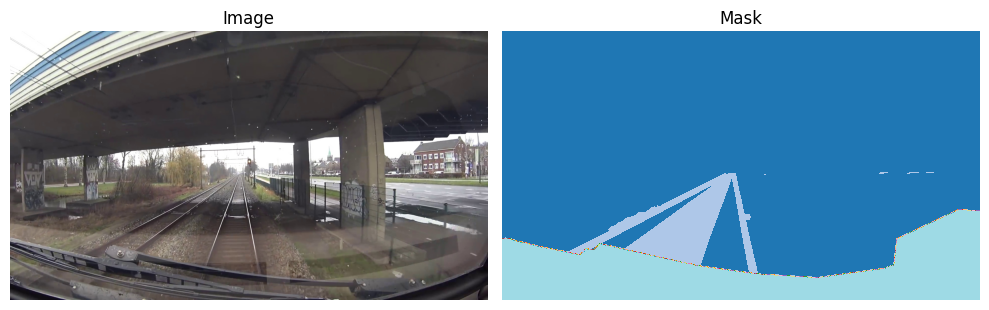

In [4]:
# --- Picking random samples to visualize ---
samples_to_show = 3
indices = random.sample(range(len(img_paths)), samples_to_show)

for idx in indices:
    img_file = img_paths[idx]
    mask_file = mask_paths[idx]
    img = Image.open(img_file)
    mask = Image.open(mask_file)

    mask_arr = np.array(mask)
    print(f"\nSample {idx+1}: {os.path.basename(img_file)}")
    print(f"- Image size: {img.size}") # (1920, 1080)
    print(f"- Mask size:  {mask.size}") # (1920, 1080)
    print(f"- Unique classes in mask: {np.unique(mask_arr)}") # [0 1 2 3 4 5 7 8 9 10 11 12 13 15 17 18 255]

    # Visualization
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img)
    axs[0].set_title('Image')
    axs[0].axis('off')
    axs[1].imshow(mask_arr, cmap='tab20')
    axs[1].set_title('Mask')
    axs[1].axis('off')
    plt.tight_layout()
    # plt.savefig(f"sample_pair_{idx+1}.png")
    plt.show()

In [7]:
# --- Parsing rs19-config.json ---
# Extract index, name, readable (description), color (RGB)
with open('data/railsem19/rs19-config.json', 'r') as f:
    config = json.load(f)
labels = config['labels']

# Build DataFrame mapping class index to name and color
class_df = pd.DataFrame([
    {
        'index': i,
        'name': label['name'],
        'description': label.get('readable', label['name']),
        'color': label['color']
    }
    for i, label in enumerate(labels)
])

print(class_df.shape)
display(class_df)

(19, 4)


,index,name,description,color
0,0,road,Road,"[128, 64, 128]"
1,1,sidewalk,Sidewalk and train platforms,"[244, 35, 232]"
2,2,construction,Construction (includes CS wall label),"[70, 70, 70]"
3,3,tram-track,Tram Track (between two rails used for driving...,"[192, 0, 128]"
4,4,fence,Fence,"[190, 153, 153]"
5,5,pole,Pole,"[153, 153, 153]"
6,6,traffic-light,Traffic Light,"[250, 170, 30]"
7,7,traffic-sign,Traffic Sign,"[220, 220, 0]"
8,8,vegetation,Vegetation,"[107, 142, 35]"
9,9,terrain,Terrain,"[152, 251, 152]"


In [ ]:
# --- Count pixels per class ---
class_df['pixel_count'] = 0
pixel_count_per_class = Counter()

for f in tqdm(masks, desc='Mask Files'):
    mask = np.array(Image.open(os.path.join(MASK_ROOT, f)))
    classes, counts = np.unique(mask, return_counts=True)
    for c, cnt in zip(classes, counts):
        if c < class_df.shape[0]: # ignore unknown labels
            pixel_count_per_class[c] += cnt

Mask Files: 100%|██████████| 8500/8500 [04:53<00:00, 29.00it/s]


In [ ]:
class_df['pixel_count'] = pixel_count_per_class
total_pixels = sum(pixel_count_per_class.values())
class_df['percentage'] = class_df['pixel_count'] / total_pixels * 100

# Sort and display
# class_df = class_df.sort_values('percentage', ascending=False)
display(class_df)

,index,name,description,color,pixel_count,percentage
0,0,road,Road,"[128, 64, 128]",566749063,3.332067
1,1,sidewalk,Sidewalk and train platforms,"[244, 35, 232]",449090153,2.640319
2,2,construction,Construction (includes CS wall label),"[70, 70, 70]",2114616629,12.432388
3,3,tram-track,Tram Track (between two rails used for driving...,"[192, 0, 128]",131426532,0.772691
4,4,fence,Fence,"[190, 153, 153]",369168634,2.170440
5,5,pole,Pole,"[153, 153, 153]",482435484,2.836365
6,6,traffic-light,Traffic Light,"[250, 170, 30]",24083165,0.141591
7,7,traffic-sign,Traffic Sign,"[220, 220, 0]",23866554,0.140318
8,8,vegetation,Vegetation,"[107, 142, 35]",4050541274,23.814198
9,9,terrain,Terrain,"[152, 251, 152]",1308637386,7.693824


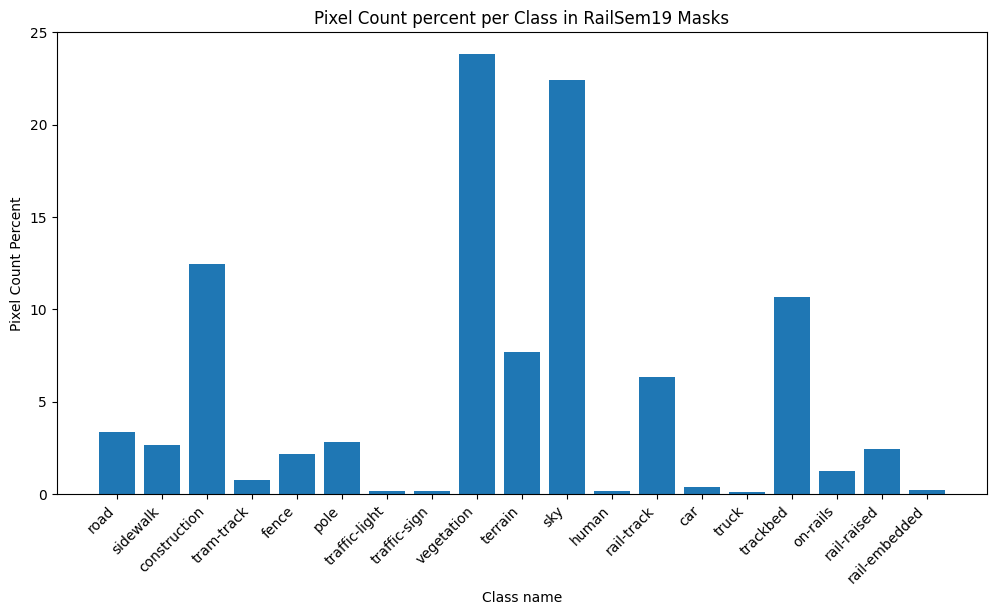

In [20]:
# Plot distribution bar chart
plt.figure(figsize=(12,6))
plt.bar(
    class_df['name'],
    class_df['percentage']
)
plt.xticks(rotation=45, ha='right')
plt.title("Pixel Count percent per Class in RailSem19 Masks")
plt.xlabel('Class name')
plt.ylabel("Pixel Count Percent")
plt.show()

In [43]:
# --- Annotation Quality ---

def check_annotation_quality(mask_paths, max_pixel_value, corruption_threshold=0.5):
    """
    Identify masks with missing or corrupted regions.
    Missing regions are detected as pixels with value outside expected class range i.e. >18
    Corruption threshold defines fraction of missing pixels to raise alert.
    
    Args:
        mask_paths (list): List containing all the mask images.
        max_pixel_value (int): Maximum valid label index in masks.
        corruption_threshold (float): Fraction of missing/corrupt pixels to flag mask.
        
    Returns:
        List of corrupted mask filenames.
    """
    corrupted_masks = []
    for f in tqdm(mask_paths, desc='Checking corruption in Mask Files'):
        mask = np.array(Image.open(os.path.join(MASK_ROOT, f)))
        
        total_pixels = mask.size
        # Count pixels outside valid class range or zero as missing/corrupt
        missing_pixels = np.sum((mask > max_pixel_value))
        
        if missing_pixels / total_pixels > corruption_threshold:
            corrupted_masks.append(f)
            
    return corrupted_masks

In [44]:
corrupted = check_annotation_quality(masks, max_pixel_value=18)
print(f"Corrupted annotation masks: {len(corrupted)}")

Checking corruption in Mask Files: 100%|██████████| 8500/8500 [01:48<00:00, 78.53it/s]

Corrupted annotation masks: 18


In [ ]:
corrupted

In [65]:
# --- Verifying whether Masks were remapped ---
mask_2_path = mask_paths[8432]
mask_2_arr = np.array(Image.open(mask_2_path), dtype=np.int64)
print("Unique labels in orig mask: ", np.unique(mask_2_arr))

processed_mask_2_path = "data/railsem19/processed_masks/rs08432.png"
pr_mask_2_arr = np.array(Image.open(processed_mask_2_path), dtype=np.int64)
print("Unique labels in remapped mask: ", np.unique(pr_mask_2_arr))

Unique labels in orig mask:  [  0   1   2   4   5   6   7   8   9  10  12  15  17 255]
Unique labels in remapped mask:  [  0   1 255]


In [69]:
# --- How many masks contain each class ---

from src.dataset import RailSem19Dataset

dataset = RailSem19Dataset()
print(f"Total dataset size: {len(dataset)} images\n")

num_samples_total = len(dataset) # 8500
num_samples = 1000

# Create random sample of 'num_samples' indices (no repeats)
random_indices = random.sample(range(num_samples_total), num_samples)

# Count images containing each class
samples_with = {0: 0, 1: 0, 2: 0}

for i in tqdm(random_indices, desc='Analyzing samples'):
    _, mask = dataset[i]
    for class_id in [0, 1, 2]:
        if (mask == class_id).any():
            samples_with[class_id] += 1

# Report
class_names = {0: "Track area", 1: "Scene context", 2: "Object"}
print("Dataset coverage (image-level):")
for c, count in samples_with.items():
    pct = count / num_samples * 100
    print(f"  {class_names[c]:15s} (class {c}): {count:5d}/{num_samples} ({pct:5.1f}%)")

c:\Users\MadhavKoodanaMadhu\Documents\MPMD\Sem3\PM and DA lab\pmda-proj\.venv\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
[INFO 2025-11-14 08:28:45] dataset: Loaded processor from facebook/dinov2-base
[INFO 2025-11-14 08:28:45] dataset: Initialized dataset with 8500 samples


Total dataset size: 8500 images



Analyzing samples: 100%|██████████| 1000/1000 [02:48<00:00,  5.95it/s]

Dataset coverage (image-level):
  Track area      (class 0):   999/1000 ( 99.9%)
  Scene context   (class 1):  1000/1000 (100.0%)
  Object          (class 2):   368/1000 ( 36.8%)
